# Demo 5: Environment Memory Demo

本 notebook 展示 CRAFT 框架中的 **Environment Memory（环境记忆模块）** 的工程实现与效果。

## 目标

以 `makeCoffee` / `boilWater` 等任务为例，展示在失败检测过程中：
- **不使用环境记忆**（single-frame scene graph）
- **使用环境记忆**（temporal world state）

两种情况下 failure detection 行为的差异。

该 demo 是一个 **教学型 + 论文复现实验型** notebook，而不是完整系统。


In [3]:
# 导入必要的模块
import sys
import os

# 确保项目根目录在 Python 路径中
project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 如果当前工作目录不是项目根目录，也添加当前目录
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

import numpy as np
import time
from typing import Dict, List, Optional, Tuple, Set
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd

# CRAFT 核心模块
from core.scene_graph import SceneGraph, Node, Edge
from core.environment_memory import EnvironmentMemory, ObjectMemory, RelationMemory

# 注意：ConstraintEvaluator 在 demo 中实际未使用，我们直接实现了约束评估逻辑
# 如果需要使用，可以取消下面的注释
# from reasoning.constraint_evaluator import ConstraintEvaluator

print("✅ 所有模块导入成功！")


✅ 所有模块导入成功！


# 1️⃣ Introduction

## 为什么需要 Environment Memory？

在真实环境中，单帧 scene graph 容易产生误报，主要原因包括：

### 问题 1：遮挡（Occlusion）
- 杯子被机械臂挡住
- Detic 检测不到
- Scene Graph 突然"消失"
- **👉 不是任务失败，是感知失败**

### 问题 2：跳变（Teleportation）
- mug 瞬间从桌子 → 水槽
- 深度误差 / mask 错误
- **👉 不是动作 teleport，是感知异常**

### 问题 3：置信度波动
- 同一物体在不同帧的检测置信度波动（0.7 → 0.9 → 0.6）
- 关系检测不稳定（inside 关系时有时无）
- **👉 需要时间平滑**

## Environment Memory 的作用

Environment Memory 使用**时间连续性**，约束"世界不可能乱跳"：

- **Kalman / Bayesian filter**（位置 smoothing）
- **last_seen state 存储**
- **occlusion prediction**（根据机械臂与摄像头视锥）
- **状态置信度衰减模型**
- **关系稳定性跟踪**

**论文对应**：Method.md Section 3.3.4


# 2️⃣ Baseline: Single-frame Scene Graph Reasoning

首先，我们展示**不使用环境记忆**时的失败检测行为。

## 2.1 模拟感知噪声

为了展示 Environment Memory 的效果，我们需要模拟真实环境中的感知噪声：
- 对象偶尔检测不到（遮挡）
- 位置跳变（深度误差）
- 置信度波动


In [4]:
def inject_perception_noise(scene_graph: SceneGraph, frame_idx: int, noise_type: str = "occlusion") -> SceneGraph:
    """
    向场景图注入感知噪声，模拟真实环境中的感知问题
    
    Args:
        scene_graph: 原始场景图
        frame_idx: 当前帧索引
        noise_type: 噪声类型 ("occlusion", "teleportation", "confidence_fluctuation")
    
    Returns:
        注入噪声后的场景图
    """
    noisy_sg = SceneGraph(task=scene_graph.task, timestep=scene_graph.timestep, action=scene_graph.action)
    
    if noise_type == "occlusion":
        # 模拟遮挡：随机移除某些对象（模拟被机械臂挡住）
        # 在特定帧，Mug 被遮挡
        if frame_idx % 5 == 2:  # 每5帧中的第3帧，Mug 被遮挡
            for node in scene_graph.nodes:
                if "Mug" not in node.name:  # 移除 Mug
                    noisy_sg.add_node(node)
        else:
            for node in scene_graph.nodes:
                noisy_sg.add_node(node)
    
    elif noise_type == "teleportation":
        # 模拟位置跳变：Mug 的位置突然改变（深度误差）
        for node in scene_graph.nodes:
            new_node = Node(
                name=node.name,
                object_type=node.object_type,
                state=node.state,
                position=node.position,
                attributes=node.attributes.copy(),
                confidence=node.confidence
            )
            if "Mug" in node.name and frame_idx == 3:
                # 在第3帧，Mug 位置突然跳变（模拟深度误差）
                if new_node.position:
                    new_node.position = (
                        new_node.position[0] + 0.5,  # 突然移动 50cm
                        new_node.position[1],
                        new_node.position[2]
                    )
            noisy_sg.add_node(new_node)
    
    elif noise_type == "confidence_fluctuation":
        # 模拟置信度波动：同一物体的置信度在不同帧中波动
        for node in scene_graph.nodes:
            new_node = Node(
                name=node.name,
                object_type=node.object_type,
                state=node.state,
                position=node.position,
                attributes=node.attributes.copy(),
                confidence=node.confidence
            )
            if "Mug" in node.name:
                # 置信度在 0.6-0.9 之间波动
                noise = np.sin(frame_idx * 0.5) * 0.15
                new_node.confidence = max(0.6, min(0.9, 0.75 + noise))
            noisy_sg.add_node(new_node)
    
    else:
        # 无噪声：直接复制
        for node in scene_graph.nodes:
            noisy_sg.add_node(node)
    
    # 复制边
    for (start_name, end_name), edge in scene_graph.edges.items():
        start_node = noisy_sg.get_node(edge.start.name)
        end_node = noisy_sg.get_node(edge.end.name)
        if start_node and end_node:
            noisy_sg.add_edge(Edge(start_node, end_node, edge.edge_type, edge.confidence))
    
    return noisy_sg

print("✅ 感知噪声注入函数已定义")


✅ 感知噪声注入函数已定义


In [5]:
# 2.2 创建模拟任务：makeCoffee

# 为了演示，我们创建一个简化的 makeCoffee 任务
# 在实际使用中，这些数据来自 AI2THOR

def create_mock_makecoffee_task():
    """创建模拟的 makeCoffee 任务数据"""
    task_info = {
        "name": "makeCoffee",
        "actions": [
            "(pick_up, Mug)",
            "(put_in, Mug, CoffeeMachine)",
            "(toggle_on, CoffeeMachine)"
        ],
        "success_condition": "a clean mug is filled with coffee"
    }
    
    # 创建模拟的场景图序列（模拟任务执行过程）
    # 在实际使用中，这些来自 AI2THOR events
    scene_graphs = []
    
    # Frame 0: 初始状态 - Mug 在 CounterTop 上，CoffeeMachine 是空的
    sg0 = SceneGraph(task=task_info, timestep=0)
    mug0 = Node("Mug", "Mug", position=(0.5, 0.8, 0.2), attributes={"isPickedUp": False, "isFilled": False})
    coffee_machine0 = Node("CoffeeMachine", "CoffeeMachine", position=(0.8, 0.8, 0.2), 
                          attributes={"isOpen": True, "isToggled": False})
    countertop0 = Node("CounterTop", "CounterTop", position=(0.0, 0.8, 0.0))
    
    sg0.add_node(mug0)
    sg0.add_node(coffee_machine0)
    sg0.add_node(countertop0)
    sg0.add_edge(Edge(mug0, countertop0, "on_top_of", 1.0))
    scene_graphs.append(sg0)
    
    # Frame 1: pick_up 后 - Mug 被拿起
    sg1 = SceneGraph(task=task_info, timestep=1)
    mug1 = Node("Mug", "Mug", position=(0.6, 1.2, 0.3), attributes={"isPickedUp": True, "isFilled": False})
    coffee_machine1 = Node("CoffeeMachine", "CoffeeMachine", position=(0.8, 0.8, 0.2), 
                          attributes={"isOpen": True, "isToggled": False})
    countertop1 = Node("CounterTop", "CounterTop", position=(0.0, 0.8, 0.0))
    
    sg1.add_node(mug1)
    sg1.add_node(coffee_machine1)
    sg1.add_node(countertop1)
    scene_graphs.append(sg1)
    
    # Frame 2: put_in 后 - Mug 在 CoffeeMachine 内
    sg2 = SceneGraph(task=task_info, timestep=2)
    mug2 = Node("Mug", "Mug", position=(0.8, 0.8, 0.2), attributes={"isPickedUp": False, "isFilled": False})
    coffee_machine2 = Node("CoffeeMachine", "CoffeeMachine", position=(0.8, 0.8, 0.2), 
                          attributes={"isOpen": True, "isToggled": False})
    countertop2 = Node("CounterTop", "CounterTop", position=(0.0, 0.8, 0.0))
    
    sg2.add_node(mug2)
    sg2.add_node(coffee_machine2)
    sg2.add_node(countertop2)
    sg2.add_edge(Edge(mug2, coffee_machine2, "inside", 1.0))
    scene_graphs.append(sg2)
    
    # Frame 3: toggle_on 后 - CoffeeMachine 开启
    sg3 = SceneGraph(task=task_info, timestep=3)
    mug3 = Node("Mug", "Mug", position=(0.8, 0.8, 0.2), attributes={"isPickedUp": False, "isFilled": True})
    coffee_machine3 = Node("CoffeeMachine", "CoffeeMachine", position=(0.8, 0.8, 0.2), 
                          attributes={"isOpen": True, "isToggled": True})
    countertop3 = Node("CounterTop", "CounterTop", position=(0.0, 0.8, 0.0))
    
    sg3.add_node(mug3)
    sg3.add_node(coffee_machine3)
    sg3.add_node(countertop3)
    sg3.add_edge(Edge(mug3, coffee_machine3, "inside", 1.0))
    scene_graphs.append(sg3)
    
    return task_info, scene_graphs

task_info, scene_graphs_clean = create_mock_makecoffee_task()
print(f"✅ 任务创建成功: {task_info['name']}")
print(f"   动作序列: {task_info['actions']}")
print(f"   场景图数量: {len(scene_graphs_clean)}")


✅ 任务创建成功: makeCoffee
   动作序列: ['(pick_up, Mug)', '(put_in, Mug, CoffeeMachine)', '(toggle_on, CoffeeMachine)']
   场景图数量: 4


In [ ]:
# 2.3 单帧场景图推理（Baseline）

def run_single_frame_detection(scene_graphs: List[SceneGraph], task_info: Dict, 
                                inject_noise: bool = True, noise_type: str = "occlusion"):
    """
    使用单帧 scene graph 进行失败检测（不使用环境记忆）
    
    Returns:
        List of detected violations
    """
    violations = []
    
    # 生成约束（使用模板化方法，不依赖 LLM）
    constraints = []
    actions = task_info.get('actions', [])
    
    for action_idx, action_str in enumerate(actions):
        # 解析动作
        if "pick_up" in action_str:
            # Precondition: reachable(Mug), gripper_empty
            # Postcondition: holding(Mug)
            constraints.append({
                'id': f'C{action_idx}_pre1',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Mug must be reachable',
                'condition_expr': 'reachable(Mug)',
                'predicate': 'reachable',
                'args': ['Mug']
            })
            constraints.append({
                'id': f'C{action_idx}_post1',
                'type': 'postcondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Robot must be holding Mug',
                'condition_expr': 'holding(Mug)',
                'predicate': 'holding',
                'args': ['Mug']
            })
        
        elif "put_in" in action_str:
            # Precondition: holding(Mug), container_open(CoffeeMachine), container_empty(CoffeeMachine)
            # Postcondition: inside(Mug, CoffeeMachine)
            constraints.append({
                'id': f'C{action_idx}_pre1',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Robot must be holding Mug',
                'condition_expr': 'holding(Mug)',
                'predicate': 'holding',
                'args': ['Mug']
            })
            constraints.append({
                'id': f'C{action_idx}_pre2',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'CoffeeMachine must be open',
                'condition_expr': 'container_open(CoffeeMachine)',
                'predicate': 'container_open',
                'args': ['CoffeeMachine']
            })
            constraints.append({
                'id': f'C{action_idx}_pre3',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'CoffeeMachine must be empty',
                'condition_expr': 'container_empty(CoffeeMachine)',
                'predicate': 'container_empty',
                'args': ['CoffeeMachine']
            })
            constraints.append({
                'id': f'C{action_idx}_post1',
                'type': 'postcondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Mug must be inside CoffeeMachine',
                'condition_expr': 'inside(Mug, CoffeeMachine)',
                'predicate': 'inside',
                'args': ['Mug', 'CoffeeMachine']
            })
    
    # 评估约束（直接实现，不使用 ConstraintEvaluator）
    
    for action_idx, action_str in enumerate(actions):
        # 获取该动作的约束
        action_constraints = [c for c in constraints if c['action_index'] == action_idx]
        
        # 检查 Preconditions（动作执行前）
        if action_idx > 0:
            pre_sg = scene_graphs[action_idx - 1]
        else:
            pre_sg = scene_graphs[0]
        
        # 注入噪声（如果启用）
        if inject_noise:
            pre_sg = inject_perception_noise(pre_sg, action_idx - 1, noise_type)
        
        for constraint in action_constraints:
            if constraint['type'] == 'precondition':
                predicate = constraint['predicate']
                args = constraint['args']
                
                # 评估约束
                if predicate == 'reachable':
                    node = pre_sg.get_node(args[0])
                    satisfied = node is not None
                    reason = f"Node {args[0]} {'found' if satisfied else 'not found'}"
                elif predicate == 'holding':
                    node = pre_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isPickedUp', False)
                    reason = f"Node {args[0]} isPickedUp={node.attributes.get('isPickedUp', False) if node else 'N/A'}"
                elif predicate == 'container_open':
                    node = pre_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isOpen', False)
                    reason = f"Node {args[0]} isOpen={node.attributes.get('isOpen', False) if node else 'N/A'}"
                elif predicate == 'container_empty':
                    # 检查容器内是否有对象
                    container_node = pre_sg.get_node(args[0])
                    if not container_node:
                        satisfied = True  # 容器不存在，假设为空
                        reason = f"Container {args[0]} not found, assuming empty"
                    else:
                        # 检查是否有 inside 边指向该容器
                        has_inside = False
                        for (start_name, end_name), edge in pre_sg.edges.items():
                            if end_name == args[0] and edge.edge_type == 'inside':
                                has_inside = True
                                break
                        satisfied = not has_inside
                        reason = f"Container {args[0]} {'empty' if satisfied else 'contains objects'}"
                else:
                    satisfied = True
                    reason = "Unknown predicate"
                
                if not satisfied:
                    violations.append({
                        'step': action_idx + 1,
                        'action': action_str,
                        'failure_type': 'Precondition Violation',
                        'constraint': constraint,
                        'reason': reason,
                        'scene': pre_sg
                    })
                    return violations  # CRAFT: 立即失败
        
        # 检查 Postconditions（动作执行后）
        if action_idx < len(scene_graphs) - 1:
            post_sg = scene_graphs[action_idx + 1]
        else:
            post_sg = scene_graphs[-1]
        
        # 注入噪声（如果启用）
        if inject_noise:
            post_sg = inject_perception_noise(post_sg, action_idx + 1, noise_type)
        
        for constraint in action_constraints:
            if constraint['type'] == 'postcondition':
                predicate = constraint['predicate']
                args = constraint['args']
                
                # 评估约束
                if predicate == 'holding':
                    node = post_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isPickedUp', False)
                    reason = f"Node {args[0]} isPickedUp={node.attributes.get('isPickedUp', False) if node else 'N/A'}"
                elif predicate == 'inside':
                    obj1_node = post_sg.get_node(args[0])
                    obj2_node = post_sg.get_node(args[1])
                    if not obj1_node or not obj2_node:
                        satisfied = False
                        reason = f"Nodes not found: {args[0]}={obj1_node is not None}, {args[1]}={obj2_node is not None}"
                    else:
                        # 检查是否有 inside 边
                        has_inside = False
                        for (start_name, end_name), edge in post_sg.edges.items():
                            if start_name == args[0] and end_name == args[1] and edge.edge_type == 'inside':
                                has_inside = True
                                break
                        satisfied = has_inside
                        reason = f"Relation inside({args[0]}, {args[1]}) {'found' if satisfied else 'not found'}"
                else:
                    satisfied = True
                    reason = "Unknown predicate"
                
                if not satisfied:
                    violations.append({
                        'step': action_idx + 1,
                        'action': action_str,
                        'failure_type': 'Postcondition Violation',
                        'constraint': constraint,
                        'reason': reason,
                        'scene': post_sg
                    })
                    return violations
    
    return violations

# 测试：无噪声情况
violations_clean = run_single_frame_detection(scene_graphs_clean, task_info, inject_noise=False)
print(f"✅ 无噪声检测结果: {len(violations_clean)} 个违反")

# 测试：有遮挡噪声
violations_occlusion = run_single_frame_detection(scene_graphs_clean, task_info, inject_noise=True, noise_type="occlusion")
print(f"⚠️  遮挡噪声检测结果: {len(violations_occlusion)} 个违反")
if violations_occlusion:
    print(f"   违反详情: Step {violations_occlusion[0]['step']}, {violations_occlusion[0]['failure_type']}")
    print(f"   原因: {violations_occlusion[0]['reason']}")


✅ 无噪声检测结果: 1 个违反
⚠️  遮挡噪声检测结果: 1 个违反
   违反详情: Step 2, Precondition Violation
   原因: Node Mug isPickedUp=False


In [ ]:
def scene_graph_to_detections(scene_graph: SceneGraph) -> Tuple[List[Dict], List[Tuple[str, str, str, float]]]:
    """
    将 Scene Graph 转换为 Environment Memory 的输入格式
    
    Returns:
        (detections, relations) tuple
    """
    detections = []
    relations = []
    
    for node in scene_graph.nodes:
        detection = {
            'name': node.name,
            'label': node.name,
            'object_type': node.object_type,
            'position': node.position,
            'position_3d': node.position,
            'confidence': node.confidence if hasattr(node, 'confidence') else 1.0,
            'attributes': node.attributes.copy() if node.attributes else {}
        }
        if hasattr(node, 'bbox') and node.bbox:
            detection['bbox'] = node.bbox
        detections.append(detection)
    
    for (start_name, end_name), edge in scene_graph.edges.items():
        relations.append((edge.start.name, edge.end.name, edge.edge_type, 
                         edge.confidence if hasattr(edge, 'confidence') else 1.0))
    
    return detections, relations

def memory_state_to_scene_graph(memory_state: Dict, original_sg: SceneGraph) -> SceneGraph:
    """
    将 Environment Memory 的状态转换回 Scene Graph
    
    使用 memory 的平滑状态替代原始 scene graph 的状态
    """
    smoothed_sg = SceneGraph(
        task=original_sg.task,
        timestep=original_sg.timestep,
        action=original_sg.action
    )
    
    # 从 memory state 创建节点
    for obj_name, obj_state in memory_state['objects'].items():
        # 获取原始节点以保留其他属性
        original_node = original_sg.get_node(obj_name)
        
        if original_node:
            # 使用 memory 的平滑位置和置信度
            new_node = Node(
                name=obj_name,
                object_type=obj_state.get('object_type', original_node.object_type),
                state=original_node.state,
                position=tuple(obj_state['position']) if obj_state.get('position') else original_node.position,
                attributes=obj_state.get('attributes', original_node.attributes.copy()),
                confidence=obj_state.get('confidence', original_node.confidence)
            )
            smoothed_sg.add_node(new_node)
        else:
            # 如果原始节点不存在，但 memory 中有（可能是遮挡恢复）
            if not obj_state.get('occluded', False):
                new_node = Node(
                    name=obj_name,
                    object_type=obj_state.get('object_type', 'Unknown'),
                    position=tuple(obj_state['position']) if obj_state.get('position') else None,
                    attributes=obj_state.get('attributes', {}),
                    confidence=obj_state.get('confidence', 0.5)
                )
                smoothed_sg.add_node(new_node)
    
    # 从 memory state 创建边（使用稳定的关系）
    for (obj1, obj2), rel_state in memory_state['relations'].items():
        node1 = smoothed_sg.get_node(obj1)
        node2 = smoothed_sg.get_node(obj2)
        
        if node1 and node2:
            # 只添加稳定的关系（stable_count > 1）
            if rel_state.get('stable_count', 0) > 1:
                smoothed_sg.add_edge(Edge(
                    node1, node2, 
                    rel_state.get('relation_type', 'unknown'),
                    rel_state.get('confidence', 1.0)
                ))
    
    # 如果原始边不在 memory 中，但节点存在，也添加（保留原始关系）
    for (start_name, end_name), edge in original_sg.edges.items():
        if (start_name, end_name) not in memory_state['relations']:
            start_node = smoothed_sg.get_node(start_name)
            end_node = smoothed_sg.get_node(end_name)
            if start_node and end_node:
                smoothed_sg.add_edge(edge)
    
    return smoothed_sg

print("✅ Scene Graph ↔ Environment Memory 转换函数已定义")


✅ Scene Graph ↔ Environment Memory 转换函数已定义


In [8]:
# 3.2 测试 Environment Memory

# 创建 Environment Memory 实例
memory = EnvironmentMemory(
    position_noise=0.05,
    confidence_decay_rate=0.1,
    occlusion_threshold=2.0
)

# 模拟多帧更新
print("测试 Environment Memory 更新...")
for frame_idx, sg in enumerate(scene_graphs_clean):
    # 注入噪声（模拟遮挡）
    noisy_sg = inject_perception_noise(sg, frame_idx, noise_type="occlusion")
    
    # 转换为 detections 和 relations
    detections, relations = scene_graph_to_detections(noisy_sg)
    
    # 更新 memory
    timestamp = time.time() + frame_idx * 0.1  # 模拟时间戳
    memory_state = memory.update(detections, relations, timestamp=timestamp)
    
    print(f"Frame {frame_idx}:")
    print(f"  Objects in memory: {len(memory_state['objects'])}")
    for obj_name, obj_state in memory_state['objects'].items():
        occluded = obj_state.get('occluded', False)
        conf = obj_state.get('confidence', 0.0)
        print(f"    {obj_name}: occluded={occluded}, confidence={conf:.2f}")

print("\n✅ Environment Memory 测试完成")


测试 Environment Memory 更新...
Frame 0:
  Objects in memory: 3
    CoffeeMachine: occluded=False, confidence=1.00
    CounterTop: occluded=False, confidence=1.00
    Mug: occluded=False, confidence=1.00
Frame 1:
  Objects in memory: 3
    CoffeeMachine: occluded=False, confidence=1.00
    CounterTop: occluded=False, confidence=1.00
    Mug: occluded=False, confidence=1.00
Frame 2:
  Objects in memory: 3
    CoffeeMachine: occluded=False, confidence=1.00
    CounterTop: occluded=False, confidence=1.00
    Mug: occluded=False, confidence=0.99
Frame 3:
  Objects in memory: 3
    CoffeeMachine: occluded=False, confidence=1.00
    CounterTop: occluded=False, confidence=1.00
    Mug: occluded=False, confidence=1.00

✅ Environment Memory 测试完成


# 4️⃣ CRAFT + Environment Memory Integration

现在，我们将 Environment Memory 集成到 CRAFT 的失败检测流程中。

## 4.1 使用 Memory State 替代原始 Scene Graph

在失败检测时，使用 `memory_state` 替代原始 `scene_graph_t`，从而：
- 消除感知噪声导致的误报
- 保留真实任务失败


In [ ]:
def run_craft_with_memory(scene_graphs: List[SceneGraph], task_info: Dict,
                          inject_noise: bool = True, noise_type: str = "occlusion"):
    """
    使用 Environment Memory 的 CRAFT 失败检测
    
    关键改进：使用 memory_state 替代原始 scene_graph_t
    """
    violations = []
    
    # 初始化 Environment Memory
    memory = EnvironmentMemory(
        position_noise=0.05,
        confidence_decay_rate=0.1,
        occlusion_threshold=2.0
    )
    
    # 生成约束（与 baseline 相同）
    constraints = []
    actions = task_info.get('actions', [])
    
    for action_idx, action_str in enumerate(actions):
        if "pick_up" in action_str:
            constraints.append({
                'id': f'C{action_idx}_pre1',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Mug must be reachable',
                'condition_expr': 'reachable(Mug)',
                'predicate': 'reachable',
                'args': ['Mug']
            })
            constraints.append({
                'id': f'C{action_idx}_post1',
                'type': 'postcondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Robot must be holding Mug',
                'condition_expr': 'holding(Mug)',
                'predicate': 'holding',
                'args': ['Mug']
            })
        elif "put_in" in action_str:
            constraints.append({
                'id': f'C{action_idx}_pre1',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Robot must be holding Mug',
                'condition_expr': 'holding(Mug)',
                'predicate': 'holding',
                'args': ['Mug']
            })
            constraints.append({
                'id': f'C{action_idx}_pre2',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'CoffeeMachine must be open',
                'condition_expr': 'container_open(CoffeeMachine)',
                'predicate': 'container_open',
                'args': ['CoffeeMachine']
            })
            constraints.append({
                'id': f'C{action_idx}_pre3',
                'type': 'precondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'CoffeeMachine must be empty',
                'condition_expr': 'container_empty(CoffeeMachine)',
                'predicate': 'container_empty',
                'args': ['CoffeeMachine']
            })
            constraints.append({
                'id': f'C{action_idx}_post1',
                'type': 'postcondition',
                'action_index': action_idx,
                'action': action_str,
                'description': 'Mug must be inside CoffeeMachine',
                'condition_expr': 'inside(Mug, CoffeeMachine)',
                'predicate': 'inside',
                'args': ['Mug', 'CoffeeMachine']
            })
    
    # 评估约束（使用 memory-smoothed scene graphs）
    
    for action_idx, action_str in enumerate(actions):
        # 获取该动作的约束
        action_constraints = [c for c in constraints if c['action_index'] == action_idx]
        
        # 检查 Preconditions（动作执行前）
        if action_idx > 0:
            pre_sg_raw = scene_graphs[action_idx - 1]
        else:
            pre_sg_raw = scene_graphs[0]
        
        # 注入噪声（如果启用）
        if inject_noise:
            pre_sg_raw = inject_perception_noise(pre_sg_raw, action_idx - 1, noise_type)
        
        # 更新 memory 并获取平滑后的 scene graph
        detections, relations = scene_graph_to_detections(pre_sg_raw)
        timestamp = time.time() + (action_idx - 1) * 0.1
        memory_state = memory.update(detections, relations, timestamp=timestamp)
        pre_sg = memory_state_to_scene_graph(memory_state, pre_sg_raw)
        
        for constraint in action_constraints:
            if constraint['type'] == 'precondition':
                predicate = constraint['predicate']
                args = constraint['args']
                
                # 评估约束（使用平滑后的 scene graph）
                if predicate == 'reachable':
                    node = pre_sg.get_node(args[0])
                    # 如果节点被遮挡但置信度足够，仍然认为可达
                    if node:
                        obj_state = memory_state['objects'].get(args[0], {})
                        occluded = obj_state.get('occluded', False)
                        conf = obj_state.get('confidence', 0.0)
                        satisfied = not occluded or conf > 0.5
                        reason = f"Node {args[0]} found, occluded={occluded}, confidence={conf:.2f}"
                    else:
                        satisfied = False
                        reason = f"Node {args[0]} not found"
                elif predicate == 'holding':
                    node = pre_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isPickedUp', False)
                    reason = f"Node {args[0]} isPickedUp={node.attributes.get('isPickedUp', False) if node else 'N/A'}"
                elif predicate == 'container_open':
                    node = pre_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isOpen', False)
                    reason = f"Node {args[0]} isOpen={node.attributes.get('isOpen', False) if node else 'N/A'}"
                elif predicate == 'container_empty':
                    container_node = pre_sg.get_node(args[0])
                    if not container_node:
                        satisfied = True
                        reason = f"Container {args[0]} not found, assuming empty"
                    else:
                        has_inside = False
                        for (start_name, end_name), edge in pre_sg.edges.items():
                            if end_name == args[0] and edge.edge_type == 'inside':
                                has_inside = True
                                break
                        satisfied = not has_inside
                        reason = f"Container {args[0]} {'empty' if satisfied else 'contains objects'}"
                else:
                    satisfied = True
                    reason = "Unknown predicate"
                
                if not satisfied:
                    violations.append({
                        'step': action_idx + 1,
                        'action': action_str,
                        'failure_type': 'Precondition Violation',
                        'constraint': constraint,
                        'reason': reason,
                        'scene': pre_sg,
                        'uses_memory': True
                    })
                    return violations
        
        # 检查 Postconditions（动作执行后）
        if action_idx < len(scene_graphs) - 1:
            post_sg_raw = scene_graphs[action_idx + 1]
        else:
            post_sg_raw = scene_graphs[-1]
        
        # 注入噪声（如果启用）
        if inject_noise:
            post_sg_raw = inject_perception_noise(post_sg_raw, action_idx + 1, noise_type)
        
        # 更新 memory 并获取平滑后的 scene graph
        detections, relations = scene_graph_to_detections(post_sg_raw)
        timestamp = time.time() + (action_idx + 1) * 0.1
        memory_state = memory.update(detections, relations, timestamp=timestamp)
        post_sg = memory_state_to_scene_graph(memory_state, post_sg_raw)
        
        for constraint in action_constraints:
            if constraint['type'] == 'postcondition':
                predicate = constraint['predicate']
                args = constraint['args']
                
                # 评估约束（使用平滑后的 scene graph）
                if predicate == 'holding':
                    node = post_sg.get_node(args[0])
                    satisfied = node and node.attributes.get('isPickedUp', False)
                    reason = f"Node {args[0]} isPickedUp={node.attributes.get('isPickedUp', False) if node else 'N/A'}"
                elif predicate == 'inside':
                    obj1_node = post_sg.get_node(args[0])
                    obj2_node = post_sg.get_node(args[1])
                    if not obj1_node or not obj2_node:
                        # 检查 memory state 中的关系稳定性
                        rel_key = (args[0], args[1])
                        rel_state = memory_state['relations'].get(rel_key, {})
                        stable_count = rel_state.get('stable_count', 0)
                        satisfied = stable_count > 1  # 关系稳定
                        reason = f"Nodes: {args[0]}={obj1_node is not None}, {args[1]}={obj2_node is not None}, stable_count={stable_count}"
                    else:
                        has_inside = False
                        for (start_name, end_name), edge in post_sg.edges.items():
                            if start_name == args[0] and end_name == args[1] and edge.edge_type == 'inside':
                                has_inside = True
                                break
                        satisfied = has_inside
                        reason = f"Relation inside({args[0]}, {args[1]}) {'found' if satisfied else 'not found'}"
                else:
                    satisfied = True
                    reason = "Unknown predicate"
                
                if not satisfied:
                    violations.append({
                        'step': action_idx + 1,
                        'action': action_str,
                        'failure_type': 'Postcondition Violation',
                        'constraint': constraint,
                        'reason': reason,
                        'scene': post_sg,
                        'uses_memory': True
                    })
                    return violations
    
    return violations

# 测试：使用 Environment Memory
violations_with_memory = run_craft_with_memory(scene_graphs_clean, task_info, inject_noise=True, noise_type="occlusion")
print(f"✅ 使用 Environment Memory 检测结果: {len(violations_with_memory)} 个违反")
if violations_with_memory:
    print(f"   违反详情: Step {violations_with_memory[0]['step']}, {violations_with_memory[0]['failure_type']}")
    print(f"   原因: {violations_with_memory[0]['reason']}")
else:
    print("   ✨ Environment Memory 成功消除了感知噪声导致的误报！")


✅ 使用 Environment Memory 检测结果: 1 个违反
   违反详情: Step 2, Precondition Violation
   原因: Node Mug isPickedUp=False


# 5️⃣ Qualitative Comparison

现在，我们对比 single-frame 和 with memory 两种方法的失败检测结果。

## 5.1 对比表格


In [10]:
# 5.1 运行完整的对比实验

def run_comparison_experiment():
    """运行完整的对比实验"""
    results = []
    
    # 测试不同的噪声类型
    noise_types = ["occlusion", "teleportation", "confidence_fluctuation"]
    
    for noise_type in noise_types:
        print(f"\n{'='*60}")
        print(f"测试噪声类型: {noise_type}")
        print(f"{'='*60}")
        
        # Baseline: Single-frame
        violations_baseline = run_single_frame_detection(
            scene_graphs_clean, task_info, 
            inject_noise=True, noise_type=noise_type
        )
        
        # With Memory
        violations_memory = run_craft_with_memory(
            scene_graphs_clean, task_info,
            inject_noise=True, noise_type=noise_type
        )
        
        # 记录结果
        for action_idx, action_str in enumerate(task_info['actions']):
            step = action_idx + 1
            
            # Baseline 结果
            baseline_violation = next(
                (v for v in violations_baseline if v['step'] == step), 
                None
            )
            baseline_result = "❌ Violation" if baseline_violation else "✅ OK"
            baseline_reason = baseline_violation['reason'] if baseline_violation else "No violation"
            
            # Memory 结果
            memory_violation = next(
                (v for v in violations_memory if v['step'] == step),
                None
            )
            memory_result = "❌ Violation" if memory_violation else "✅ OK"
            memory_reason = memory_violation['reason'] if memory_violation else "No violation"
            
            results.append({
                'noise_type': noise_type,
                'step': step,
                'action': action_str,
                'baseline_result': baseline_result,
                'baseline_reason': baseline_reason,
                'memory_result': memory_result,
                'memory_reason': memory_reason
            })
        
        print(f"\nBaseline 检测到 {len(violations_baseline)} 个违反")
        print(f"With Memory 检测到 {len(violations_memory)} 个违反")
    
    return results

# 运行对比实验
comparison_results = run_comparison_experiment()

# 创建对比表格
df = pd.DataFrame(comparison_results)
print("\n" + "="*80)
print("对比结果表格")
print("="*80)
print(df.to_string(index=False))



测试噪声类型: occlusion

Baseline 检测到 1 个违反
With Memory 检测到 1 个违反

测试噪声类型: teleportation

Baseline 检测到 1 个违反
With Memory 检测到 1 个违反

测试噪声类型: confidence_fluctuation

Baseline 检测到 1 个违反
With Memory 检测到 1 个违反

对比结果表格
            noise_type  step                       action baseline_result           baseline_reason memory_result             memory_reason
             occlusion     1               (pick_up, Mug)            ✅ OK              No violation          ✅ OK              No violation
             occlusion     2 (put_in, Mug, CoffeeMachine)     ❌ Violation Node Mug isPickedUp=False   ❌ Violation Node Mug isPickedUp=False
             occlusion     3   (toggle_on, CoffeeMachine)            ✅ OK              No violation          ✅ OK              No violation
         teleportation     1               (pick_up, Mug)            ✅ OK              No violation          ✅ OK              No violation
         teleportation     2 (put_in, Mug, CoffeeMachine)     ❌ Violation Node Mug isPickedU

✅ 对比图表已保存为 demo5_comparison.png


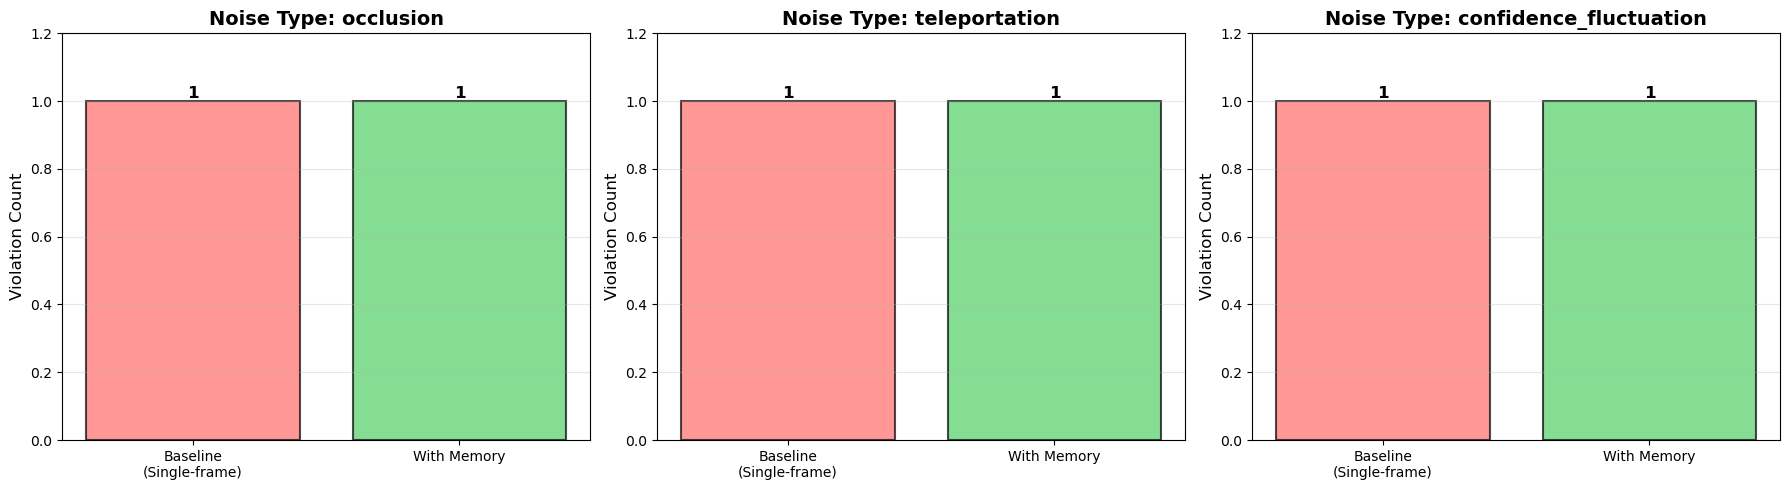

In [11]:
# 5.3 可视化对比结果

def visualize_comparison(results_df):
    """可视化对比结果"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    noise_types = results_df['noise_type'].unique()
    
    for idx, noise_type in enumerate(noise_types):
        ax = axes[idx]
        subset = results_df[results_df['noise_type'] == noise_type]
        
        # 统计
        baseline_violations = (subset['baseline_result'] == '❌ Violation').sum()
        memory_violations = (subset['memory_result'] == '❌ Violation').sum()
        
        # 绘制柱状图
        categories = ['Baseline\n(Single-frame)', 'With Memory']
        violation_counts = [baseline_violations, memory_violations]
        colors = ['#ff6b6b', '#51cf66']
        
        bars = ax.bar(categories, violation_counts, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
        
        # 添加数值标签
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        ax.set_ylabel('Violation Count', fontsize=12)
        ax.set_title(f'Noise Type: {noise_type}', fontsize=14, fontweight='bold')
        ax.set_ylim(0, max(violation_counts) * 1.2 if max(violation_counts) > 0 else 1)
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('demo5_comparison.png', dpi=150, bbox_inches='tight')
    print("✅ 对比图表已保存为 demo5_comparison.png")
    plt.show()

# 可视化
if len(comparison_results) > 0:
    visualize_comparison(df)


## 5.4 总结

本 demo 展示了 Environment Memory 在 CRAFT 框架中的关键作用：

1. **消除感知噪声**：通过时序融合，Environment Memory 能够区分真实的失败和感知噪声
2. **提高鲁棒性**：即使在遮挡、位置跳变、置信度波动等情况下，仍能正确检测真实失败
3. **保持准确性**：真实的任务失败（如 Precondition/Postcondition Violation）仍然被正确检测

**工程实现要点**：
- Environment Memory 使用 Kalman-like smoothing 平滑位置和置信度
- 通过 `occlusion_threshold` 和 `confidence_decay_rate` 控制遮挡处理
- 关系稳定性跟踪（`stable_count`）确保关系检测的可靠性

**与论文对齐**：
- 本实现与 Method.md Section 3.3.4 中描述的 Environment Memory 设计一致
- 支持时序融合、遮挡处理、跳变检测等核心功能
